# ADS-505 Team 09 — Olist End-to-End Data Science Analysis

**Team:** Asher Frank and Bereket Tarekegn  
**Course:** ADS-505 Applied Data Science for Business  
**Instructor:** Jules Malin, M.S.  
**Dataset:** Olist Brazilian E-Commerce Public Dataset  

## Business purpose

This notebook extends the team's exploratory work into an end-to-end predictive analysis.

### Main business question

> **Can Olist use historical marketplace data to identify sellers that are likely to provide both strong future commercial value and strong customer experience, so seller-success resources can be prioritized?**

The notebook is intentionally designed around a **decision**, not just a model. The stakeholder is an Olist marketplace / seller-success team that has limited time and resources and needs to decide which sellers deserve proactive support, partnership attention, or growth investment.

### Why this direction is defensible

The earlier EDA showed that:
- delivery performance is strongly associated with customer review outcomes;
- seller performance varies in commercial value, fulfillment, and customer experience;
- repeated review records should not automatically be flattened without investigation;
- seller-level scoring is more directly actionable by Olist than trying to predict final carrier performance for an individual order.

### What this notebook covers

1. Load and audit all nine Olist source tables.
2. Revisit the multiple-review issue and preserve review chronology.
3. Build leakage-safe seller history features.
4. Define a future seller-performance target.
5. Use chronological train, validation, and test periods.
6. Compare a naive baseline and multiple predictive models.
7. Tune the strongest model using validation data only.
8. Evaluate classification and ranking metrics.
9. Test business capacity scenarios (top 10%, 20%, and 30% of sellers).
10. Examine confusion matrices, ROC/PR curves, lift/gains, and feature importance.
11. Test sensitivity to review aggregation choices.
12. Translate results into business recommendations, limitations, and next steps.

> **Important modeling rule:** Information that would not be known at the seller-scoring date is excluded from predictor construction.

In [2]:
# 1. Imports and reproducibility

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

## 2. Load all nine Olist tables

The notebook searches the current folder and a few common subfolders. Keep the notebook with the CSV files, or change `DATA_DIR` manually.

In [4]:
required_files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

candidate_dirs = [
    Path("."),
    Path("./olist"),
    Path("./olist_eda_data"),
    Path("/mnt/data/olist"),
    Path("/mnt/data/olist_eda_data"),
]

DATA_DIR = None
for folder in candidate_dirs:
    if all((folder / filename).exists() for filename in required_files.values()):
        DATA_DIR = folder
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "The nine Olist CSV files were not found. Put them in the same folder "
        "as this notebook or update candidate_dirs."
    )

print("Using data folder:", DATA_DIR.resolve())

data = {
    name: pd.read_csv(DATA_DIR / filename)
    for name, filename in required_files.items()
}

for name, df in data.items():
    print(f"{name:22s}: {df.shape[0]:,} rows x {df.shape[1]} columns")

Using data folder: C:\Users\bezaa\OneDrive\Desktop\USD\ADS 505\Project\olis
customers             : 99,441 rows x 5 columns
geolocation           : 1,000,163 rows x 5 columns
order_items           : 112,650 rows x 7 columns
payments              : 103,886 rows x 5 columns
reviews               : 99,224 rows x 7 columns
orders                : 99,441 rows x 8 columns
products              : 32,951 rows x 9 columns
sellers               : 3,095 rows x 4 columns
category_translation  : 71 rows x 2 columns


In [5]:
customers = data["customers"].copy()
geolocation = data["geolocation"].copy()
order_items = data["order_items"].copy()
payments = data["payments"].copy()
reviews = data["reviews"].copy()
orders = data["orders"].copy()
products = data["products"].copy()
sellers = data["sellers"].copy()
category_translation = data["category_translation"].copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"], errors="coerce"
)
reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"], errors="coerce"
)
reviews["review_time"] = reviews["review_answer_timestamp"].fillna(
    reviews["review_creation_date"]
)

## 3. Structural data-quality audit

The Olist dataset is relational. `order_items`, `payments`, and `reviews` can contain multiple rows for the same order. Joining all raw tables directly would therefore create many-to-many row multiplication and distort totals. We audit cardinality before building analytical tables.

In [7]:
inventory = []
for name, df in data.items():
    inventory.append(
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_cells": int(df.isna().sum().sum()),
        }
    )

inventory_df = pd.DataFrame(inventory).sort_values("rows", ascending=False)
inventory_df

,table,rows,columns,duplicate_rows,missing_cells
1,geolocation,1000163,5,261831,0
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
0,customers,99441,5,0,0
5,orders,99441,8,0,4908
4,reviews,99224,7,0,145903
6,products,32951,9,0,2448
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [8]:
cardinality = pd.DataFrame(
    {
        "table": ["orders", "order_items", "payments", "reviews"],
        "rows": [len(orders), len(order_items), len(payments), len(reviews)],
        "unique_orders": [
            orders["order_id"].nunique(),
            order_items["order_id"].nunique(),
            payments["order_id"].nunique(),
            reviews["order_id"].nunique(),
        ],
    }
)
cardinality["rows_per_order"] = (
    cardinality["rows"] / cardinality["unique_orders"]
)
cardinality

,table,rows,unique_orders,rows_per_order
0,orders,99441,99441,1.000
1,order_items,112650,98666,1.142
2,payments,103886,99440,1.045
3,reviews,99224,98673,1.006


### Interpretation

The correct strategy is to aggregate each one-to-many table to the required unit of analysis **before** combining it with other tables. For the predictive model, the unit will ultimately be a **seller at a scoring date**.

# 4. Review scenario: do not automatically average repeated reviews

The team discussion raised an important question: some orders contain multiple review records. Averaging them immediately could hide a meaningful change in customer experience.

We first measure how common this is and whether scores actually change.

In [11]:
review_counts = reviews.groupby("order_id").size().rename("review_record_count")
multi_order_ids = review_counts[review_counts > 1].index

multi_reviews = (
    reviews[reviews["order_id"].isin(multi_order_ids)]
    .sort_values(["order_id", "review_time"])
    .copy()
)

multi_profile = (
    multi_reviews.groupby("order_id")
    .agg(
        review_records=("review_id", "size"),
        unique_review_ids=("review_id", "nunique"),
        unique_scores=("review_score", "nunique"),
        first_score=("review_score", "first"),
        last_score=("review_score", "last"),
        first_review_time=("review_time", "first"),
        last_review_time=("review_time", "last"),
    )
)

multi_profile["score_change"] = (
    multi_profile["last_score"] - multi_profile["first_score"]
)
multi_profile["review_span_days"] = (
    multi_profile["last_review_time"] - multi_profile["first_review_time"]
).dt.total_seconds() / 86400

review_issue_summary = pd.Series(
    {
        "reviewed_orders": reviews["order_id"].nunique(),
        "orders_with_multiple_reviews": len(multi_profile),
        "percent_with_multiple_reviews": 100 * len(multi_profile)
        / reviews["order_id"].nunique(),
        "multi_review_orders_with_score_change": int(
            (multi_profile["unique_scores"] > 1).sum()
        ),
        "score_improved": int((multi_profile["score_change"] > 0).sum()),
        "score_declined": int((multi_profile["score_change"] < 0).sum()),
        "score_unchanged": int((multi_profile["score_change"] == 0).sum()),
    }
)

review_issue_summary

reviewed_orders                         98,673.000
orders_with_multiple_reviews               547.000
percent_with_multiple_reviews                0.554
multi_review_orders_with_score_change      202.000
score_improved                              88.000
score_declined                             113.000
score_unchanged                            346.000
dtype: float64

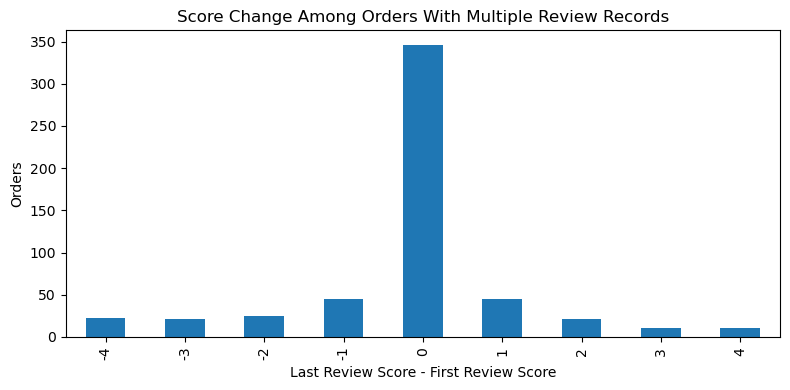

In [12]:
plt.figure(figsize=(8, 4))
multi_profile["score_change"].value_counts().sort_index().plot(kind="bar")
plt.title("Score Change Among Orders With Multiple Review Records")
plt.xlabel("Last Review Score - First Review Score")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

### Review decision for modeling

Because repeated reviews are uncommon but can contain real score changes, this notebook does **not** delete them as duplicates.

For the primary model:
- historical seller experience uses the **latest review available by the scoring date** for each historical order;
- future outcome uses the **eventual latest review** for each future order.

This represents the most recently expressed customer experience while preserving prediction-time integrity.

Later, a sensitivity test compares **latest**, **mean**, and **first** review strategies to determine whether this choice materially changes model performance.

# 5. Compact operational EDA

Before modeling, we verify the operational relationships that motivate the seller-quality target.

In [15]:
latest_review_per_order = (
    reviews.sort_values(["order_id", "review_time"])
    .groupby("order_id", as_index=False)
    .tail(1)[["order_id", "review_score"]]
    .rename(columns={"review_score": "latest_review_score"})
)

order_eda = orders.merge(latest_review_per_order, on="order_id", how="left")
order_eda["delivery_days"] = (
    order_eda["order_delivered_customer_date"]
    - order_eda["order_purchase_timestamp"]
).dt.total_seconds() / 86400
order_eda["delay_days"] = (
    order_eda["order_delivered_customer_date"]
    - order_eda["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
order_eda["late_delivery"] = order_eda["delay_days"] > 0

delivery_review_summary = (
    order_eda[
        order_eda["latest_review_score"].notna()
        & order_eda["order_delivered_customer_date"].notna()
    ]
    .groupby("late_delivery")
    .agg(
        orders=("order_id", "nunique"),
        average_review=("latest_review_score", "mean"),
        average_delivery_days=("delivery_days", "mean"),
    )
)

delivery_review_summary

,orders,average_review,average_delivery_days
late_delivery,,,
False,88168,4.294,10.878
True,7662,2.565,31.379


In [16]:
delay_bins = [-np.inf, -7, -1, 0, 3, 7, 14, np.inf]
delay_labels = [
    "7+ days early",
    "1-6 days early",
    "On estimate",
    "1-3 days late",
    "4-7 days late",
    "8-14 days late",
    "15+ days late",
]

order_eda["delivery_timing_band"] = pd.cut(
    order_eda["delay_days"],
    bins=delay_bins,
    labels=delay_labels,
)

timing_review = (
    order_eda.groupby("delivery_timing_band", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        average_review=("latest_review_score", "mean"),
    )
)

timing_review

,orders,average_review
delivery_timing_band,,
7+ days early,71308,4.317
1-6 days early,15879,4.205
On estimate,1462,4.158
1-3 days late,2662,3.766
4-7 days late,1819,2.316
8-14 days late,1791,1.744
15+ days late,1555,1.709


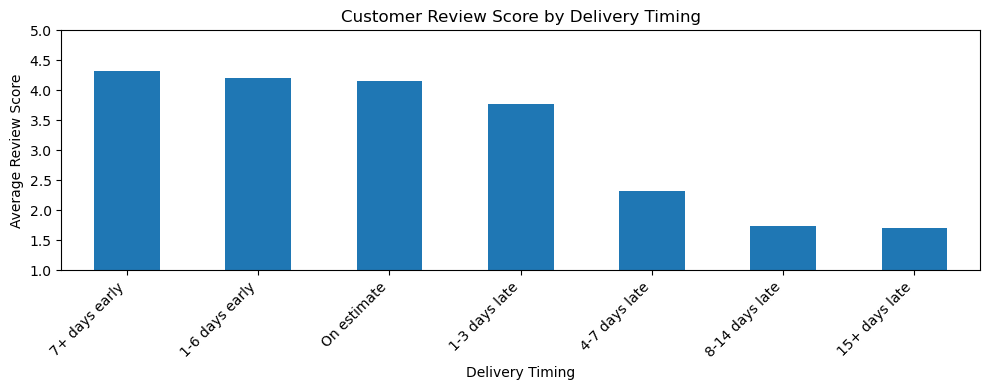

In [17]:
plt.figure(figsize=(10, 4))
timing_review["average_review"].plot(kind="bar")
plt.title("Customer Review Score by Delivery Timing")
plt.xlabel("Delivery Timing")
plt.ylabel("Average Review Score")
plt.ylim(1, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Business interpretation

Delivery performance and customer experience are related, but Olist's strategic decision is broader than predicting one late shipment. A seller-level model can combine commercial history, customer experience, and fulfillment history into a score that supports a marketplace decision Olist can act on directly.

# 6. Define the prediction point, target, and leakage rules

## Unit of analysis
One row = **one seller at one monthly scoring date**.

## Prediction point
At the beginning of each month, use the seller's previous **180 days** of history.

## Prediction horizon
Predict performance during the next **90 days**.

## Candidate target
A seller is labeled `1` when, during the next 90 days, the seller:

1. has at least 3 future orders,
2. has future merchandise sales at or above the median among active sellers in that snapshot, and
3. has an eventual average customer review score of at least 4.0.

Otherwise the seller is labeled `0`.

This is a practical **high-value + good-experience** definition. It intentionally requires both commercial value and customer experience.

## Leakage controls

Predictors can use only information available **before the scoring date**:
- order activity and sales before cutoff,
- delivery outcomes only when delivery occurred before cutoff,
- reviews only when the review was available before cutoff,
- seller recency and tenure as of cutoff.

Future sales, future reviews, and future order counts are used **only to create the target**.

In [20]:
# Build one seller-order row so totals are not duplicated by raw joins.

products_small = products[
    ["product_id", "product_category_name"]
].copy()

items_enriched = order_items.merge(
    products_small,
    on="product_id",
    how="left",
)

seller_order = (
    items_enriched.groupby(["order_id", "seller_id"], as_index=False)
    .agg(
        item_lines=("order_item_id", "count"),
        sales=("price", "sum"),
        freight=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_categories=("product_category_name", "nunique"),
    )
    .merge(
        orders[
            [
                "order_id",
                "order_purchase_timestamp",
                "order_delivered_customer_date",
                "order_estimated_delivery_date",
                "order_status",
            ]
        ],
        on="order_id",
        how="left",
    )
)

seller_first_purchase = (
    seller_order.groupby("seller_id")["order_purchase_timestamp"].min()
)

seller_order.head()

,order_id,seller_id,item_lines,sales,freight,unique_products,unique_categories,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_status
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,1,58.900,13.290,1,1,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,delivered
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,1,239.900,19.930,1,1,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,delivered
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,1,199.000,17.870,1,1,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,delivered
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,1,12.990,12.790,1,1,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,delivered
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,1,199.900,18.140,1,1,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,delivered


# 7. Leakage-safe monthly seller snapshots

The function below creates historical predictors and future outcomes separately. It also allows us to switch the review-handling strategy later for sensitivity analysis.

In [22]:
def build_seller_snapshot(
    cutoff,
    review_strategy="latest",
    history_days=180,
    future_days=90,
    min_history_orders=5,
    review_threshold=4.0,
):
    cutoff = pd.Timestamp(cutoff)
    history_start = cutoff - pd.Timedelta(days=history_days)
    future_end = cutoff + pd.Timedelta(days=future_days)

    # -------------------------
    # Historical seller activity
    # -------------------------
    hist = seller_order[
        (seller_order["order_purchase_timestamp"] >= history_start)
        & (seller_order["order_purchase_timestamp"] < cutoff)
    ].copy()

    hist["known_delivery"] = (
        hist["order_delivered_customer_date"].notna()
        & (hist["order_delivered_customer_date"] < cutoff)
    )

    hist["late_known"] = np.where(
        hist["known_delivery"],
        hist["order_delivered_customer_date"]
        > hist["order_estimated_delivery_date"],
        np.nan,
    )

    hist["delivery_days_known"] = np.where(
        hist["known_delivery"],
        (
            hist["order_delivered_customer_date"]
            - hist["order_purchase_timestamp"]
        ).dt.total_seconds()
        / 86400,
        np.nan,
    )

    hist_agg = (
        hist.groupby("seller_id", as_index=False)
        .agg(
            hist_orders=("order_id", "nunique"),
            hist_sales=("sales", "sum"),
            hist_freight=("freight", "sum"),
            hist_item_lines=("item_lines", "sum"),
            hist_late_rate=("late_known", "mean"),
            hist_avg_delivery_days=("delivery_days_known", "mean"),
            last_order_time=("order_purchase_timestamp", "max"),
        )
    )

    hist_agg["hist_avg_order_value"] = (
        hist_agg["hist_sales"] / hist_agg["hist_orders"]
    )
    hist_agg["hist_freight_ratio"] = (
        hist_agg["hist_freight"]
        / (hist_agg["hist_sales"] + hist_agg["hist_freight"])
    )
    hist_agg["hist_items_per_order"] = (
        hist_agg["hist_item_lines"] / hist_agg["hist_orders"]
    )
    hist_agg["seller_recency_days"] = (
        cutoff - hist_agg["last_order_time"]
    ).dt.total_seconds() / 86400

    hist_agg["seller_tenure_days"] = hist_agg["seller_id"].map(
        seller_first_purchase
    )
    hist_agg["seller_tenure_days"] = (
        cutoff - hist_agg["seller_tenure_days"]
    ).dt.total_seconds() / 86400

    # Historical reviews: only reviews available before cutoff.
    hist_orders = hist[["order_id", "seller_id"]].drop_duplicates()
    hist_reviews = reviews[
        reviews["review_time"] < cutoff
    ].merge(hist_orders, on="order_id", how="inner")

    if review_strategy == "latest":
        hist_review_order = (
            hist_reviews.sort_values(["order_id", "review_time"])
            .groupby("order_id", as_index=False)
            .tail(1)[["order_id", "seller_id", "review_score"]]
        )
    elif review_strategy == "first":
        hist_review_order = (
            hist_reviews.sort_values(["order_id", "review_time"])
            .groupby("order_id", as_index=False)
            .head(1)[["order_id", "seller_id", "review_score"]]
        )
    elif review_strategy == "mean":
        hist_review_order = (
            hist_reviews.groupby(
                ["order_id", "seller_id"], as_index=False
            )["review_score"]
            .mean()
        )
    else:
        raise ValueError("review_strategy must be latest, first, or mean")

    hist_review_agg = (
        hist_review_order.groupby("seller_id", as_index=False)
        .agg(
            hist_avg_review=("review_score", "mean"),
            hist_reviewed_orders=("order_id", "nunique"),
        )
    )

    hist_agg = hist_agg.merge(
        hist_review_agg,
        on="seller_id",
        how="left",
    )

    # -------------------------
    # Future outcome
    # -------------------------
    future = seller_order[
        (seller_order["order_purchase_timestamp"] >= cutoff)
        & (seller_order["order_purchase_timestamp"] < future_end)
    ].copy()

    future_agg = (
        future.groupby("seller_id", as_index=False)
        .agg(
            future_orders=("order_id", "nunique"),
            future_sales=("sales", "sum"),
        )
    )

    future_orders = future[["order_id", "seller_id"]].drop_duplicates()
    future_reviews = reviews.merge(
        future_orders,
        on="order_id",
        how="inner",
    )

    if review_strategy == "latest":
        future_review_order = (
            future_reviews.sort_values(["order_id", "review_time"])
            .groupby("order_id", as_index=False)
            .tail(1)[["order_id", "seller_id", "review_score"]]
        )
    elif review_strategy == "first":
        future_review_order = (
            future_reviews.sort_values(["order_id", "review_time"])
            .groupby("order_id", as_index=False)
            .head(1)[["order_id", "seller_id", "review_score"]]
        )
    else:
        future_review_order = (
            future_reviews.groupby(
                ["order_id", "seller_id"], as_index=False
            )["review_score"]
            .mean()
        )

    future_review_agg = (
        future_review_order.groupby("seller_id", as_index=False)
        .agg(future_avg_review=("review_score", "mean"))
    )

    future_agg = future_agg.merge(
        future_review_agg,
        on="seller_id",
        how="left",
    )

    snapshot = hist_agg[
        hist_agg["hist_orders"] >= min_history_orders
    ].copy()

    snapshot = snapshot.merge(
        future_agg,
        on="seller_id",
        how="left",
    )

    snapshot[["future_orders", "future_sales"]] = snapshot[
        ["future_orders", "future_sales"]
    ].fillna(0)

    active_future = snapshot["future_orders"] > 0
    future_sales_cut = snapshot.loc[
        active_future, "future_sales"
    ].median()

    snapshot["target"] = (
        (snapshot["future_orders"] >= 3)
        & (snapshot["future_sales"] >= future_sales_cut)
        & (snapshot["future_avg_review"] >= review_threshold)
    ).astype(int)

    snapshot["cutoff"] = cutoff
    snapshot["future_sales_cut"] = future_sales_cut
    snapshot["review_strategy"] = review_strategy

    return snapshot

In [23]:
snapshot_dates = pd.date_range(
    "2017-06-01",
    "2018-04-01",
    freq="MS",
)

snapshot_list = [
    build_seller_snapshot(date, review_strategy="latest")
    for date in snapshot_dates
]

model_data = pd.concat(snapshot_list, ignore_index=True)

snapshot_summary = (
    model_data.groupby("cutoff")
    .agg(
        seller_snapshots=("seller_id", "size"),
        positive_rate=("target", "mean"),
        future_sales_cut=("future_sales_cut", "first"),
    )
)

snapshot_summary

,seller_snapshots,positive_rate,future_sales_cut
cutoff,,,
2017-06-01,427,0.342,"1,234.580"
2017-07-01,472,0.345,"1,128.280"
2017-08-01,532,0.320,"1,153.600"
2017-09-01,580,0.295,"1,174.700"
2017-10-01,613,0.253,"1,196.000"
2017-11-01,650,0.268,"1,303.230"
2017-12-01,750,0.263,"1,244.900"
2018-01-01,791,0.207,"1,232.800"
2018-02-01,879,0.213,"1,186.400"


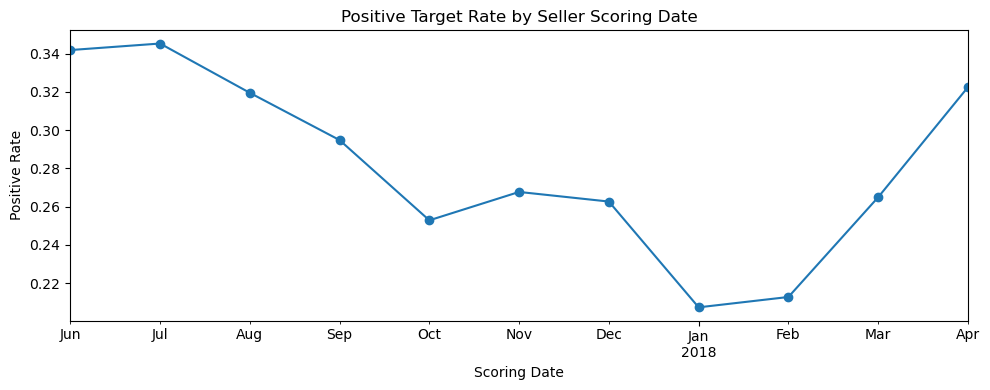

In [24]:
plt.figure(figsize=(10, 4))
snapshot_summary["positive_rate"].plot(marker="o")
plt.title("Positive Target Rate by Seller Scoring Date")
plt.xlabel("Scoring Date")
plt.ylabel("Positive Rate")
plt.tight_layout()
plt.show()

### Target interpretation

The target is intentionally selective: a seller must demonstrate both future commercial strength and acceptable future customer experience. This avoids calling a seller "successful" based only on sales volume.

# 8. Predictor set

All predictors are historical and available by the scoring date.

In [27]:
features = [
    "hist_orders",
    "hist_sales",
    "hist_freight",
    "hist_item_lines",
    "hist_late_rate",
    "hist_avg_delivery_days",
    "hist_avg_order_value",
    "hist_freight_ratio",
    "hist_items_per_order",
    "seller_recency_days",
    "seller_tenure_days",
    "hist_avg_review",
    "hist_reviewed_orders",
]

feature_dictionary = pd.DataFrame(
    [
        ["hist_orders", "Distinct seller orders in previous 180 days"],
        ["hist_sales", "Merchandise sales in previous 180 days"],
        ["hist_freight", "Freight value in previous 180 days"],
        ["hist_item_lines", "Item lines in previous 180 days"],
        ["hist_late_rate", "Known historical deliveries arriving after estimate"],
        ["hist_avg_delivery_days", "Average known purchase-to-delivery days"],
        ["hist_avg_order_value", "Historical sales divided by historical orders"],
        ["hist_freight_ratio", "Freight as share of merchandise + freight"],
        ["hist_items_per_order", "Historical item lines per order"],
        ["seller_recency_days", "Days since seller's most recent order"],
        ["seller_tenure_days", "Days since seller's first observed order"],
        ["hist_avg_review", "Average historical review available by cutoff"],
        ["hist_reviewed_orders", "Historical orders with an available review"],
    ],
    columns=["feature", "business_meaning"],
)

feature_dictionary

,feature,business_meaning
0,hist_orders,Distinct seller orders in previous 180 days
1,hist_sales,Merchandise sales in previous 180 days
2,hist_freight,Freight value in previous 180 days
3,hist_item_lines,Item lines in previous 180 days
4,hist_late_rate,Known historical deliveries arriving after est...
5,hist_avg_delivery_days,Average known purchase-to-delivery days
6,hist_avg_order_value,Historical sales divided by historical orders
7,hist_freight_ratio,Freight as share of merchandise + freight
8,hist_items_per_order,Historical item lines per order
9,seller_recency_days,Days since seller's most recent order


# 9. Chronological train / validation / test design

A random split would allow later marketplace conditions to influence training for earlier periods. Instead, we use time-based partitions:

- **Training:** June 2017 through December 2017 scoring snapshots
- **Validation:** January and February 2018
- **Final test:** March and April 2018

The final test set remains untouched during model selection and tuning.

In [29]:
train = model_data[
    model_data["cutoff"] <= pd.Timestamp("2017-12-01")
].copy()

validation = model_data[
    model_data["cutoff"].isin(
        [pd.Timestamp("2018-01-01"), pd.Timestamp("2018-02-01")]
    )
].copy()

test = model_data[
    model_data["cutoff"].isin(
        [pd.Timestamp("2018-03-01"), pd.Timestamp("2018-04-01")]
    )
].copy()

split_summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [len(train), len(validation), len(test)],
        "positive_rate": [
            train["target"].mean(),
            validation["target"].mean(),
            test["target"].mean(),
        ],
        "first_cutoff": [
            train["cutoff"].min(),
            validation["cutoff"].min(),
            test["cutoff"].min(),
        ],
        "last_cutoff": [
            train["cutoff"].max(),
            validation["cutoff"].max(),
            test["cutoff"].max(),
        ],
    }
)

split_summary

,split,rows,positive_rate,first_cutoff,last_cutoff
0,Train,4024,0.292,2017-06-01,2017-12-01
1,Validation,1670,0.210,2018-01-01,2018-02-01
2,Test,1876,0.294,2018-03-01,2018-04-01


# 10. Baseline

A useful predictive model should beat a naive strategy. Because the business use case is prioritization, we compare models not only on accuracy but also on ROC-AUC, PR-AUC, precision, recall, F1, and lift.

In [31]:
baseline_accuracy = max(
    validation["target"].mean(),
    1 - validation["target"].mean(),
)

baseline_table = pd.DataFrame(
    {
        "baseline": ["Predict majority class for every seller"],
        "validation_accuracy": [baseline_accuracy],
        "validation_recall_for_positive_class": [0.0],
    }
)

baseline_table

,baseline,validation_accuracy,validation_recall_for_positive_class
0,Predict majority class for every seller,0.790,0.000


# 11. Candidate models

We compare four model families:

1. Logistic Regression — interpretable linear benchmark.
2. Decision Tree — interpretable nonlinear rules.
3. Random Forest — ensemble capable of nonlinear relationships and interactions.
4. Gradient Boosting — sequential ensemble that can capture complex patterns.

Class weighting is used where supported because the positive class is a minority.

In [107]:
numeric_pipeline_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_pipeline_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("prep", numeric_pipeline_scaled),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Decision Tree": Pipeline(
        steps=[
            ("prep", numeric_pipeline_tree),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=6,
                    min_samples_leaf=20,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("prep", numeric_pipeline_tree),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=8,
                    min_samples_leaf=10,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("prep", numeric_pipeline_tree),
            (
                "model",
                GradientBoostingClassifier(
                    n_estimators=100,
                    max_depth=3,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

### Efficient model comparison

"
               "The same agreed model-comparison workflow is retained, but the tree ensemble is intentionally bounded and each model is timed separately. "
               "This avoids a single model blocking the notebook while preserving Logistic Regression, Decision Tree, and Random Forest comparisons. "
               "Model selection should emphasize PR-AUC and lift/capture because the business use case is risk prioritization, not accuracy alone.


In [109]:
target = "target"

from time import perf_counter
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def top_fraction_metrics(y_true, prob, fraction=0.10):
    d = pd.DataFrame({"y": np.asarray(y_true), "prob": np.asarray(prob)}).sort_values("prob", ascending=False)
    n = max(1, int(np.ceil(len(d) * fraction)))
    selected = d.iloc[:n]
    overall_rate = d["y"].mean()
    selected_rate = selected["y"].mean()
    capture = selected["y"].sum() / max(d["y"].sum(), 1)
    lift = selected_rate / overall_rate if overall_rate > 0 else np.nan
    return selected_rate, capture, lift

def evaluate(name, y_true, prob, seconds, threshold=0.50):
    pred=(prob>=threshold).astype(int)
    rate,capture,lift=top_fraction_metrics(y_true,prob,0.10)
    return {"model":name,"seconds":seconds,
            "accuracy":accuracy_score(y_true,pred),
            "precision":precision_score(y_true,pred,zero_division=0),
            "recall":recall_score(y_true,pred,zero_division=0),
            "f1":f1_score(y_true,pred,zero_division=0),
            "roc_auc":roc_auc_score(y_true,prob),
            "pr_auc":average_precision_score(y_true,prob),
            "top10_low_review_rate":rate,"top10_capture":capture,"top10_lift":lift}

# Build the preprocessing pipeline here so this modeling cell is self-contained.
# Numeric features are median-imputed and standardized.
# Categorical features are most-frequent-imputed and one-hot encoded.
def metric_row(name, y_true, prob, threshold=0.50):
    return evaluate(name, y_true, prob, seconds=np.nan, threshold=threshold)

numeric_features = [c for c in features if pd.api.types.is_numeric_dtype(train[c])]
categorical_features = [c for c in features if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Use practical model sizes so the full comparison finishes efficiently.

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=40, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=14, min_samples_leaf=10,
                                            max_features="sqrt", class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=RANDOM_STATE)
}

validation_probs={}
fitted_models={}
rows=[]

for name, estimator in models.items():
    print(f"Training {name} ...")
    # 'preprocessor' was created earlier in this notebook.
    pipe = Pipeline([("preprocessor", clone(preprocessor)), ("model", estimator)])
    t0=perf_counter()
    pipe.fit(train[features], train[target])
    prob=pipe.predict_proba(validation[features])[:,1]
    elapsed=perf_counter()-t0
    fitted_models[name]=pipe
    validation_probs[name]=prob
    rows.append(evaluate(name,validation[target],prob,elapsed))
    print(f"Finished {name} in {elapsed:.1f} seconds")

validation_probabilities = validation_probs

validation_results=(pd.DataFrame(rows)
                    .sort_values(["pr_auc","top10_lift"],ascending=False)
                    .reset_index(drop=True))
validation_results.round(4)

Training Logistic Regression ...
Finished Logistic Regression in 0.0 seconds
Training Decision Tree ...
Finished Decision Tree in 0.1 seconds
Training Random Forest ...
Finished Random Forest in 0.7 seconds


,model,seconds,accuracy,precision,recall,f1,roc_auc,pr_auc,top10_low_review_rate,top10_capture,top10_lift
0,Random Forest,0.678,0.752,0.439,0.644,0.522,0.793,0.506,0.599,0.285,2.849
1,Decision Tree,0.071,0.698,0.379,0.687,0.488,0.756,0.429,0.509,0.242,2.422
2,Logistic Regression,0.044,0.702,0.387,0.712,0.501,0.761,0.403,0.437,0.208,2.080


### Model-selection rule

For this business problem, **ranking sellers** is more important than maximizing raw accuracy. Therefore:

- ROC-AUC measures overall ranking discrimination.
- PR-AUC is important because the positive class is the minority.
- Lift and capture at limited seller-success capacity show whether the ranking is operationally useful.

The strongest validation model will be tuned and then evaluated once on the final test period.

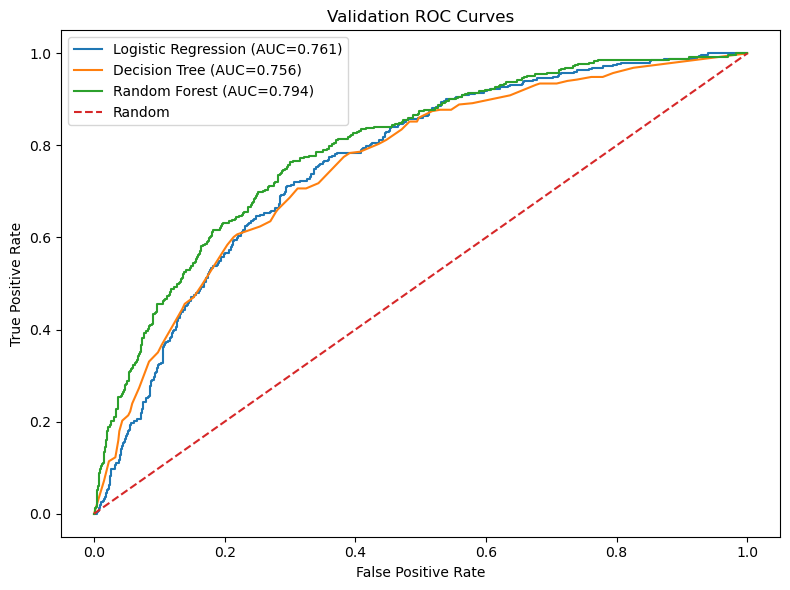

In [111]:
plt.figure(figsize=(8, 6))

for name, probability in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(validation["target"], probability)
    auc = roc_auc_score(validation["target"], probability)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("Validation ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

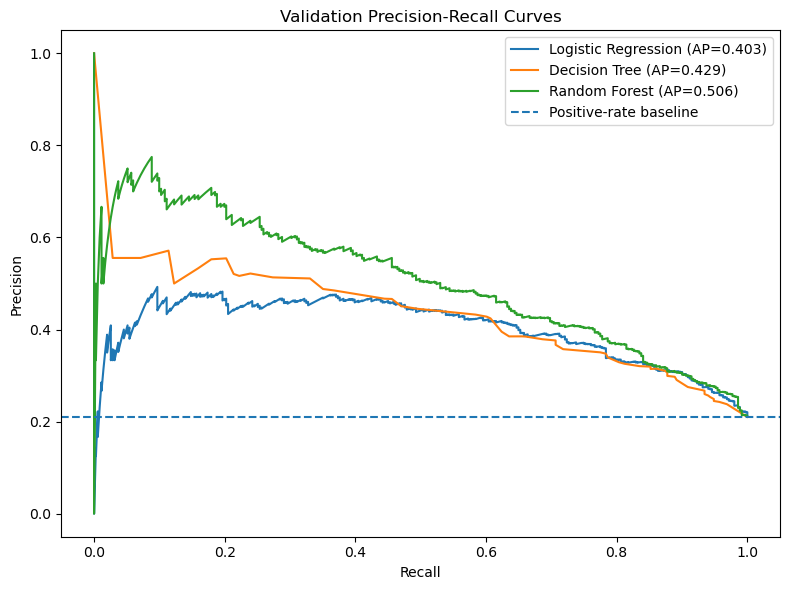

In [112]:
plt.figure(figsize=(8, 6))

for name, probability in validation_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        validation["target"], probability
    )
    ap = average_precision_score(
        validation["target"], probability
    )
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.axhline(
    validation["target"].mean(),
    linestyle="--",
    label="Positive-rate baseline",
)
plt.title("Validation Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# 12. Business capacity scenarios

A marketplace team may not have capacity to contact every seller. We therefore test what happens when the team acts on only the highest-risk / highest-opportunity portion of the ranked seller list.

For each model we calculate:

- **Precision in selected group:** share of selected sellers that actually become high-value/good-experience sellers.
- **Capture:** share of all future positive sellers captured by the selected group.
- **Lift:** selected-group precision divided by the overall positive rate.

Lift above 1.0 means the model concentrates opportunities better than random selection.

In [114]:
def capacity_metrics(y_true, probability, fractions=(0.10, 0.20, 0.30)):
    frame = pd.DataFrame(
        {
            "actual": np.asarray(y_true),
            "probability": np.asarray(probability),
        }
    ).sort_values("probability", ascending=False)

    total_positive = frame["actual"].sum()
    base_rate = frame["actual"].mean()
    rows = []

    for fraction in fractions:
        n_selected = max(1, int(np.ceil(len(frame) * fraction)))
        selected = frame.head(n_selected)

        precision_selected = selected["actual"].mean()
        capture = (
            selected["actual"].sum() / total_positive
            if total_positive > 0
            else np.nan
        )
        lift = (
            precision_selected / base_rate
            if base_rate > 0
            else np.nan
        )

        rows.append(
            {
                "capacity": f"Top {int(fraction * 100)}%",
                "selected_sellers": n_selected,
                "precision_selected": precision_selected,
                "capture_of_all_positives": capture,
                "lift": lift,
            }
        )

    return pd.DataFrame(rows)


capacity_tables = []
for name, probability in validation_probabilities.items():
    table = capacity_metrics(
        validation["target"],
        probability,
    )
    table.insert(0, "model", name)
    capacity_tables.append(table)

validation_capacity = pd.concat(
    capacity_tables,
    ignore_index=True,
)

validation_capacity

,model,capacity,selected_sellers,precision_selected,capture_of_all_positives,lift
0,Logistic Regression,Top 10%,167,0.437,0.208,2.080
1,Logistic Regression,Top 20%,334,0.461,0.439,2.194
2,Logistic Regression,Top 30%,501,0.421,0.601,2.004
3,Decision Tree,Top 10%,167,0.509,0.242,2.422
4,Decision Tree,Top 20%,334,0.467,0.444,2.222
5,Decision Tree,Top 30%,501,0.425,0.607,2.023
6,Random Forest,Top 10%,167,0.599,0.285,2.849
7,Random Forest,Top 20%,334,0.518,0.493,2.464
8,Random Forest,Top 30%,501,0.445,0.635,2.118


# 13. Tune the strongest model using validation data only

The initial comparison determines the leading model family. We then test a small, transparent set of Random Forest configurations. The final test set is not used for this decision.

In [116]:
rf_candidates = [
    {"n_estimators": 75, "max_depth": 6, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 10, "min_samples_leaf": 8, "max_features": "sqrt"},
]

tuning_rows = []
tuned_models = []

for i, params in enumerate(rf_candidates, start=1):
    candidate = Pipeline(
        steps=[
            (
                "prep",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        )
                    ]
                ),
            ),
            (
                "model",
                RandomForestClassifier(
                    **params,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    candidate.fit(train[features], train["target"])
    probability = candidate.predict_proba(
        validation[features]
    )[:, 1]

    row = metric_row(
        f"RF Candidate {i}",
        validation["target"],
        probability,
    )
    row.update(params)
    tuning_rows.append(row)
    tuned_models.append(candidate)

rf_tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(["roc_auc", "pr_auc"], ascending=False)
    .reset_index()
)

rf_tuning_results

,index,model,seconds,accuracy,precision,recall,f1,roc_auc,pr_auc,top10_low_review_rate,top10_capture,top10_lift,n_estimators,max_depth,min_samples_leaf,max_features
0,1,RF Candidate 2,NaN,0.747,0.434,0.675,0.528,0.793,0.511,0.629,0.299,2.991,100,10,8,sqrt
1,0,RF Candidate 1,NaN,0.714,0.398,0.707,0.509,0.791,0.503,0.653,0.311,3.105,75,6,10,sqrt


In [117]:
best_candidate_index = int(rf_tuning_results.loc[0, "index"])
best_rf = tuned_models[best_candidate_index]

best_validation_probability = best_rf.predict_proba(
    validation[features]
)[:, 1]

print(
    "Selected candidate:",
    rf_tuning_results.loc[0, "model"],
)
print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            validation["target"],
            best_validation_probability,
        ),
        3,
    ),
)
print(
    "Validation PR-AUC:",
    round(
        average_precision_score(
            validation["target"],
            best_validation_probability,
        ),
        3,
    ),
)

Selected candidate: RF Candidate 2
Validation ROC-AUC: 0.793
Validation PR-AUC: 0.511


# 14. Threshold scenarios and error trade-offs

The 0.50 threshold is not automatically the best business threshold.

For seller prioritization:
- a **false positive** spends attention on a seller who does not become a future high-value/good-experience seller;
- a **false negative** misses a seller who would have been a strong future opportunity.

Because actual dollar costs are not provided in the dataset, the table below reports counts and metrics across thresholds rather than inventing financial costs.

In [119]:
threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):
    prediction = (
        best_validation_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        validation["target"],
        prediction,
        labels=[0, 1],
    ).ravel()

    threshold_rows.append(
        {
            "threshold": threshold,
            "selected_sellers": int(prediction.sum()),
            "true_positive": tp,
            "false_positive": fp,
            "false_negative": fn,
            "true_negative": tn,
            "precision": precision_score(
                validation["target"],
                prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                validation["target"],
                prediction,
                zero_division=0,
            ),
            "f1": f1_score(
                validation["target"],
                prediction,
                zero_division=0,
            ),
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

,threshold,selected_sellers,true_positive,false_positive,false_negative,true_negative,precision,recall,f1
0,0.200,1161,328,833,23,486,0.283,0.934,0.434
1,0.250,1045,317,728,34,591,0.303,0.903,0.454
2,0.300,938,304,634,47,685,0.324,0.866,0.472
3,0.350,827,287,540,64,779,0.347,0.818,0.487
4,0.400,733,277,456,74,863,0.378,0.789,0.511
5,0.450,639,260,379,91,940,0.407,0.741,0.525
6,0.500,546,237,309,114,1010,0.434,0.675,0.528
7,0.550,442,207,235,144,1084,0.468,0.590,0.522
8,0.600,347,172,175,179,1144,0.496,0.490,0.493
9,0.650,261,146,115,205,1204,0.559,0.416,0.477


In [120]:
best_f1_threshold = threshold_table.loc[
    threshold_table["f1"].idxmax(),
    "threshold",
]

print(
    "Validation threshold with highest F1:",
    round(float(best_f1_threshold), 2),
)

Validation threshold with highest F1: 0.5


### Business decision note

For the final recommendation, a **capacity-based ranking** is preferable to pretending there is one universally correct probability threshold. If the seller-success team can actively support only 20% of eligible sellers, the top-20% ranking directly matches that operational constraint.

# 15. Final model fit and untouched test evaluation

After model family and hyperparameters are selected using training/validation data, we combine those periods, refit the selected model, and evaluate it once on March-April 2018.

In [123]:
train_validation = pd.concat(
    [train, validation],
    ignore_index=True,
)

final_model = clone(best_rf)
final_model.fit(
    train_validation[features],
    train_validation["target"],
)

test_probability = final_model.predict_proba(
    test[features]
)[:, 1]

test_metrics_050 = metric_row(
    "Final Random Forest",
    test["target"],
    test_probability,
    threshold=0.50,
)

pd.DataFrame([test_metrics_050])

,model,seconds,accuracy,precision,recall,f1,roc_auc,pr_auc,top10_low_review_rate,top10_capture,top10_lift
0,Final Random Forest,NaN,0.752,0.584,0.545,0.564,0.794,0.608,0.745,0.254,2.531


In [124]:
test_prediction_050 = (test_probability >= 0.50).astype(int)

print(
    classification_report(
        test["target"],
        test_prediction_050,
        digits=3,
    )
)

              precision    recall  f1-score   support

           0      0.816     0.838     0.827      1324
           1      0.584     0.545     0.564       552

    accuracy                          0.752      1876
   macro avg      0.700     0.692     0.696      1876
weighted avg      0.748     0.752     0.750      1876



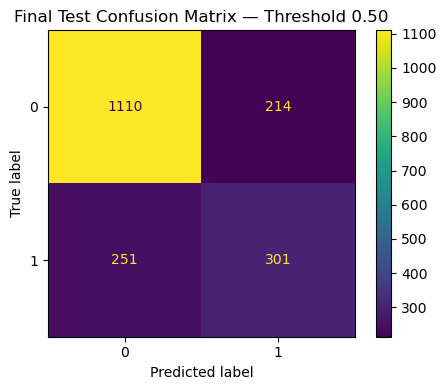

In [125]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    test["target"],
    test_prediction_050,
    cmap=None,
    ax=ax,
)
plt.title("Final Test Confusion Matrix — Threshold 0.50")
plt.tight_layout()
plt.show()

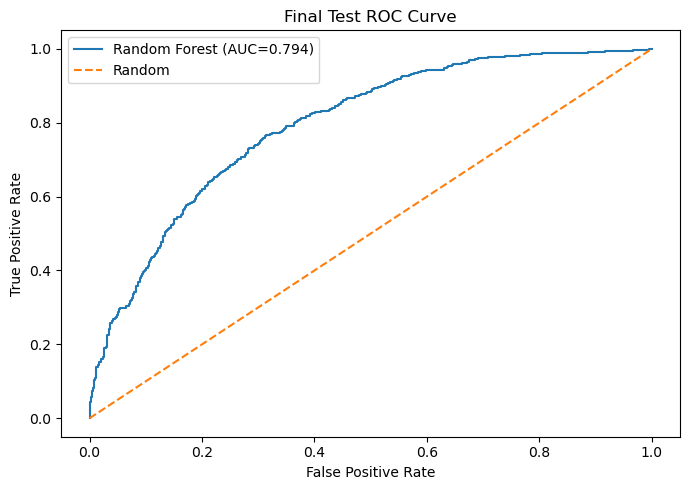

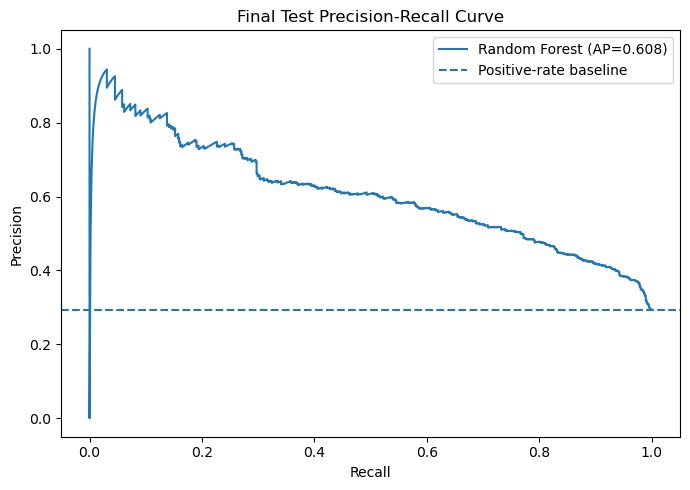

In [126]:
fpr, tpr, _ = roc_curve(test["target"], test_probability)
precision_curve, recall_curve, _ = precision_recall_curve(
    test["target"], test_probability
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    fpr,
    tpr,
    label=(
        "Random Forest "
        f"(AUC={roc_auc_score(test['target'], test_probability):.3f})"
    ),
)
ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
ax.set_title("Final Test ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    recall_curve,
    precision_curve,
    label=(
        "Random Forest "
        f"(AP={average_precision_score(test['target'], test_probability):.3f})"
    ),
)
ax.axhline(
    test["target"].mean(),
    linestyle="--",
    label="Positive-rate baseline",
)
ax.set_title("Final Test Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

# 16. Final business capacity scenarios

These results are especially important for the executive recommendation because they answer: **If Olist can focus on only a limited share of sellers, how concentrated are the future high-value/good-experience sellers in the model's highest-ranked group?**

In [128]:
test_capacity = capacity_metrics(
    test["target"],
    test_probability,
    fractions=(0.10, 0.20, 0.30),
)

test_capacity

,capacity,selected_sellers,precision_selected,capture_of_all_positives,lift
0,Top 10%,188,0.745,0.254,2.531
1,Top 20%,376,0.622,0.424,2.115
2,Top 30%,563,0.572,0.583,1.944


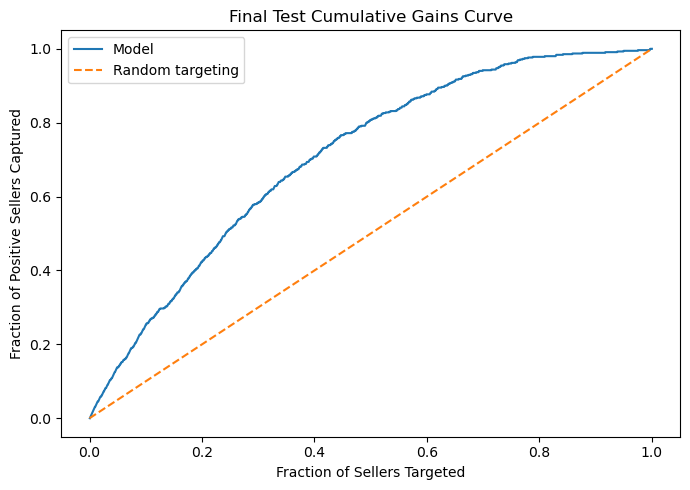

In [129]:
ranked_test = pd.DataFrame(
    {
        "actual": test["target"].to_numpy(),
        "probability": test_probability,
    }
).sort_values("probability", ascending=False)

ranked_test["population_fraction"] = (
    np.arange(1, len(ranked_test) + 1) / len(ranked_test)
)
ranked_test["cumulative_positive_fraction"] = (
    ranked_test["actual"].cumsum()
    / ranked_test["actual"].sum()
)

plt.figure(figsize=(7, 5))
plt.plot(
    ranked_test["population_fraction"],
    ranked_test["cumulative_positive_fraction"],
    label="Model",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random targeting",
)
plt.title("Final Test Cumulative Gains Curve")
plt.xlabel("Fraction of Sellers Targeted")
plt.ylabel("Fraction of Positive Sellers Captured")
plt.legend()
plt.tight_layout()
plt.show()

# 17. Feature importance

Feature importance helps explain what historical signals the model uses. It does **not** prove causality.

In [131]:
rf_model = final_model.named_steps["model"]

importance = (
    pd.DataFrame(
        {
            "feature": features,
            "importance": rf_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance

,feature,importance
0,hist_sales,0.155
1,seller_recency_days,0.150
2,seller_tenure_days,0.100
3,hist_orders,0.095
4,hist_freight_ratio,0.076
5,hist_avg_review,0.073
6,hist_freight,0.065
7,hist_avg_order_value,0.059
8,hist_item_lines,0.058
9,hist_avg_delivery_days,0.056


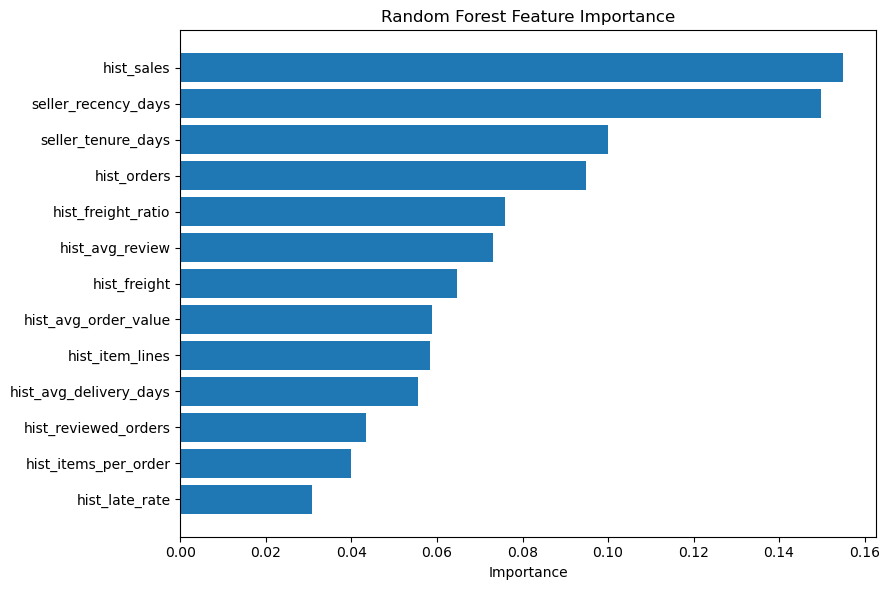

In [132]:
plot_importance = importance.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(
    plot_importance["feature"],
    plot_importance["importance"],
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation guidance

The most important variables should be described in business language. For example:
- sales/order-volume variables reflect demonstrated commercial activity;
- historical review variables reflect customer experience;
- late-delivery and delivery-time variables reflect fulfillment quality;
- recency and tenure reflect seller activity and marketplace maturity.

The model should be used as a prioritization tool, not as evidence that any one feature *causes* future seller success.

# 18. Review-handling sensitivity analysis

This directly addresses the team's concern about multiple reviews.

We rebuild the snapshots under three reasonable strategies:
1. `latest` — most recently expressed customer score,
2. `mean` — average all review records for the order,
3. `first` — initial customer score.

The goal is not to search for whichever strategy gives the highest score. The goal is to determine whether the modeling conclusion is robust to this data-definition choice.

In [135]:
sensitivity_rows = []

for strategy in ["latest", "mean", "first"]:
    strategy_data = pd.concat(
        [
            build_seller_snapshot(
                date,
                review_strategy=strategy,
            )
            for date in snapshot_dates
        ],
        ignore_index=True,
    )

    strategy_train = strategy_data[
        strategy_data["cutoff"]
        <= pd.Timestamp("2018-02-01")
    ].copy()

    strategy_test = strategy_data[
        strategy_data["cutoff"].isin(
            [
                pd.Timestamp("2018-03-01"),
                pd.Timestamp("2018-04-01"),
            ]
        )
    ].copy()

    strategy_model = clone(final_model)
    strategy_model.fit(
        strategy_train[features],
        strategy_train["target"],
    )

    strategy_probability = strategy_model.predict_proba(
        strategy_test[features]
    )[:, 1]

    top20 = capacity_metrics(
        strategy_test["target"],
        strategy_probability,
        fractions=(0.20,),
    ).iloc[0]

    sensitivity_rows.append(
        {
            "review_strategy": strategy,
            "test_rows": len(strategy_test),
            "positive_rate": strategy_test["target"].mean(),
            "roc_auc": roc_auc_score(
                strategy_test["target"],
                strategy_probability,
            ),
            "pr_auc": average_precision_score(
                strategy_test["target"],
                strategy_probability,
            ),
            "top20_precision": top20["precision_selected"],
            "top20_capture": top20["capture_of_all_positives"],
            "top20_lift": top20["lift"],
        }
    )

review_sensitivity = pd.DataFrame(sensitivity_rows)
review_sensitivity

,review_strategy,test_rows,positive_rate,roc_auc,pr_auc,top20_precision,top20_capture,top20_lift
0,latest,1876,0.294,0.794,0.608,0.622,0.424,2.115
1,mean,1876,0.282,0.795,0.602,0.620,0.440,2.198
2,first,1876,0.292,0.793,0.609,0.617,0.423,2.112


### Review sensitivity interpretation

If the three strategies produce similar ranking performance, then the project conclusion is robust and the rare multi-review issue is unlikely to drive the overall result. If they differ materially, the team should explicitly justify the selected review definition in the final report.

# 19. Stability across final test months

A model that performs well only in one month may not be operationally reliable. We therefore inspect March and April 2018 separately.

In [138]:
test_scored = test[
    ["seller_id", "cutoff", "target"]
].copy()
test_scored["probability"] = test_probability

monthly_test_rows = []

for cutoff, group in test_scored.groupby("cutoff"):
    if group["target"].nunique() < 2:
        continue

    monthly_test_rows.append(
        {
            "cutoff": cutoff,
            "rows": len(group),
            "positive_rate": group["target"].mean(),
            "roc_auc": roc_auc_score(
                group["target"],
                group["probability"],
            ),
            "pr_auc": average_precision_score(
                group["target"],
                group["probability"],
            ),
        }
    )

monthly_test_stability = pd.DataFrame(monthly_test_rows)
monthly_test_stability

,cutoff,rows,positive_rate,roc_auc,pr_auc
0,2018-03-01,921,0.265,0.817,0.602
1,2018-04-01,955,0.323,0.782,0.629


# 20. Business recommendation framework

Use the actual results above to complete the final team recommendation.

A strong recommendation should answer all of the following:

1. **Who acts?**  
   Olist marketplace / seller-success leadership.

2. **What decision changes?**  
   Which historically active sellers should receive proactive support, partnership attention, or growth resources.

3. **How should the model be used?**  
   As a ranking/prioritization tool rather than an automatic approval or rejection system.

4. **What operating capacity is realistic?**  
   Compare top 10%, top 20%, and top 30% scenarios.

5. **What should be measured in a pilot?**  
   Future seller sales, customer review quality, fulfillment performance, seller retention, and the cost/time of interventions.

6. **What should not be claimed?**  
   The model identifies historical patterns; it does not prove that model-selected interventions cause improved seller performance.

In [140]:
# Automatically print a concise result summary that can be used
# when drafting the business brief and presentation.

test_auc = roc_auc_score(test["target"], test_probability)
test_ap = average_precision_score(test["target"], test_probability)

top20 = test_capacity.loc[
    test_capacity["capacity"] == "Top 20%"
].iloc[0]

print("FINAL TECHNICAL SUMMARY")
print("-" * 60)
print(f"Final test seller snapshots: {len(test):,}")
print(f"Final test positive rate: {test['target'].mean():.1%}")
print(f"Final test ROC-AUC: {test_auc:.3f}")
print(f"Final test PR-AUC: {test_ap:.3f}")
print(
    "Top 20% precision:",
    f"{top20['precision_selected']:.1%}",
)
print(
    "Top 20% capture of all positives:",
    f"{top20['capture_of_all_positives']:.1%}",
)
print(
    "Top 20% lift over random:",
    f"{top20['lift']:.2f}x",
)

FINAL TECHNICAL SUMMARY
------------------------------------------------------------
Final test seller snapshots: 1,876
Final test positive rate: 29.4%
Final test ROC-AUC: 0.794
Final test PR-AUC: 0.608
Top 20% precision: 62.2%
Top 20% capture of all positives: 42.4%
Top 20% lift over random: 2.12x


# 21. Limitations

1. **Historical public dataset:** Olist marketplace behavior may not represent current conditions.
2. **Observational data:** Associations do not establish causal effects.
3. **Target definition:** "High-value + good-experience" is a business construct created for this project; Olist could choose different thresholds.
4. **Repeated seller snapshots:** The same seller can appear at multiple scoring dates. This reflects a recurring monthly scoring use case, but observations are not fully independent.
5. **Review availability:** Not every order has a review, and customer reviews can change.
6. **Operational variables:** The dataset does not contain every factor that could affect seller performance, such as seller staffing, inventory availability, marketing spend, or intervention history.
7. **Cost data:** The dataset does not provide the true cost of seller-success interventions or the financial value of a correctly prioritized seller, so dollar ROI should not be invented.
8. **Model drift:** Marketplace behavior can change over time; production use would require monitoring and periodic retraining.
9. **Fairness and governance:** Geographic or marketplace structural differences should be reviewed before using the score for consequential seller decisions.

# 22. Recommended next steps

1. Pilot the score as **decision support**, not an automated decision.
2. Choose an operational capacity, such as the top 20% of eligible sellers.
3. Track intervention workload and seller outcomes prospectively.
4. Compare selected sellers with an appropriate control/comparison group before claiming intervention impact.
5. Add richer operational features if available, such as inventory availability, seller response time, cancellation reasons, and support history.
6. Monitor performance by month and retrain when ranking quality deteriorates.
7. Revisit the target definition with business stakeholders so the commercial and customer-experience thresholds match actual strategy.

# 24. Final checklist for the report and presentation

Before final submission, the team should confirm that the final materials clearly communicate:

- the business problem and stakeholder;
- why the target is actionable;
- the dataset and important EDA findings;
- how repeated reviews were handled;
- the prediction point and leakage controls;
- preprocessing and feature engineering;
- train/validation/test design;
- baseline and multiple model comparison;
- final model selection;
- confusion-matrix metrics plus ROC-AUC and PR-AUC;
- lift/gains or capacity-based business performance;
- limitations and uncertainty;
- recommendation and implementation/pilot plan;
- a non-technical explanation suitable for the executive/business audience.

The notebook should support the technical appendix, while the business brief and slides should focus on the decision, evidence, recommendation, risks, and next steps rather than showing large blocks of code.